# Clasificación supervisada
## Comparación de representaciones tiempo-frecuencia: STFT vs CWT vs SST vs WPD

Este notebook implementa la etapa final del proyecto: entrenar y evaluar
modelos de clasificación supervisada sobre los datasets de features extraídos
en los notebooks anteriores, con el objetivo de determinar qué representación
tiempo-frecuencia produce features de mayor utilidad predictiva.

Se comparan **cuatro técnicas**:
- **STFT** (Short-Time Fourier Transform): ventana deslizante en el dominio de Fourier.
- **CWT** (Continuous Wavelet Transform): análisis multiresolución con wavelet continua.
- **SST** (Synchrosqueezed Transform): variante de CWT que compacta la energía en torno a las frecuencias instantáneas.
- **WPD** (Wavelet Packet Decomposition): descomposición en paquetes de wavelets con igual resolución en altas y bajas frecuencias.

---

## Contexto: lo que sabemos antes de clasificar

El análisis estadístico del notebook 05 estableció los siguientes hallazgos:

1. **La CWT supera a la STFT en las cuatro métricas de discriminabilidad**
   (Cohen's $d$, Mann-Whitney, FDR y Mutual Information).

2. **La ventaja de la CWT es topográficamente anómala:** los canales más
   discriminativos son frontales y temporales, no los occipitales y parietales
   donde el ritmo alfa debería predominar.

3. **La entropía espectral es degenerada en CWT** (CV = 1.5%), por lo que
   no aportará poder discriminativo en esa técnica.

4. **El centro de gravedad (`cog`)** es la feature más robusta y
   fisiológicamente coherente en ambas técnicas.

---

## Decisiones de diseño

### Clasificadores seleccionados

| Clasificador | Justificación |
|---|---|
| Regresión Logística | Baseline lineal |
| SVM (kernel RBF) | Robusto con muestras pequeñas y alta dimensión |
| Random Forest | Maneja multicolinealidad; entrega importancia de features |

### Configuraciones de features

**Config A — Todos los canales (56 features):** permite al clasificador
usar cualquier canal, incluyendo los frontales y temporales.

**Config B — Solo canales relevantes para el alfa (16 features):** restringe
el análisis a O1, O2, P7 y P8.

### Total de combinaciones

4 técnicas × 2 configuraciones × 3 clasificadores = **24 combinaciones**.

---

## Estructura del notebook

**Sección 1:** preparación de datos — carga, split temporal y escalado.

**Sección 2:** entrenamiento y evaluación — 24 combinaciones. Tabla comparativa.

**Sección 3:** importancia de features — análisis del Random Forest para las 4 técnicas.

**Sección 4:** síntesis y conclusiones.


# Sección 1: Preparación de Datos

Split temporal sin data leakage, selección de configuraciones de features, y escalado.

In [61]:
# Sección 1: Preparación de Datos
## Cargar datasets tabulares

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.base import clone
import warnings
warnings.filterwarnings('ignore')

# Paleta de colores fija para las 4 técnicas
COLORS = {
    'STFT': '#2980b9',
    'CWT':  "#fcf805",
    'SST':  '#27ae60',
    'WPD':  '#e67e22',
}
TECNICAS = ['STFT', 'CWT', 'SST', 'WPD']

# Cargar los cuatro datasets
features_stft = pd.read_csv('data/features/features_stft.csv')
features_cwt  = pd.read_csv('data/features/features_cwt.csv')
features_sst  = pd.read_csv('data/features/features_sst.csv')
features_wpd  = pd.read_csv('data/features/features_wpd.csv')

y_stft = features_stft['label'].values
y_cwt  = features_cwt['label'].values
y_sst  = features_sst['label'].values
y_wpd  = features_wpd['label'].values

X_stft = features_stft.drop('label', axis=1).values
X_cwt  = features_cwt.drop('label',  axis=1).values
X_sst  = features_sst.drop('label',  axis=1).values
X_wpd  = features_wpd.drop('label',  axis=1).values

print('Shape de cada dataset:')
for name, X, y in [('STFT', X_stft, y_stft), ('CWT', X_cwt, y_cwt),
                   ('SST',  X_sst,  y_sst),  ('WPD', X_wpd, y_wpd)]:
    print(f'  {name}: X={X.shape}, clase 0={np.sum(y==0)}, clase 1={np.sum(y==1)}')

print(f'\nNombres de features ({len(features_stft.columns)-1}):')
print(features_stft.columns[:-1].tolist())


Shape de cada dataset:
  STFT: X=(231, 56), clase 0=125, clase 1=106
  CWT: X=(231, 56), clase 0=125, clase 1=106
  SST: X=(231, 56), clase 0=125, clase 1=106
  WPD: X=(231, 56), clase 0=125, clase 1=106

Nombres de features (56):
['AF3_alpha_abs', 'AF3_alpha_rel', 'AF3_entropy', 'AF3_cog', 'F7_alpha_abs', 'F7_alpha_rel', 'F7_entropy', 'F7_cog', 'F3_alpha_abs', 'F3_alpha_rel', 'F3_entropy', 'F3_cog', 'FC5_alpha_abs', 'FC5_alpha_rel', 'FC5_entropy', 'FC5_cog', 'T7_alpha_abs', 'T7_alpha_rel', 'T7_entropy', 'T7_cog', 'P7_alpha_abs', 'P7_alpha_rel', 'P7_entropy', 'P7_cog', 'O1_alpha_abs', 'O1_alpha_rel', 'O1_entropy', 'O1_cog', 'O2_alpha_abs', 'O2_alpha_rel', 'O2_entropy', 'O2_cog', 'P8_alpha_abs', 'P8_alpha_rel', 'P8_entropy', 'P8_cog', 'T8_alpha_abs', 'T8_alpha_rel', 'T8_entropy', 'T8_cog', 'FC6_alpha_abs', 'FC6_alpha_rel', 'FC6_entropy', 'FC6_cog', 'F4_alpha_abs', 'F4_alpha_rel', 'F4_entropy', 'F4_cog', 'F8_alpha_abs', 'F8_alpha_rel', 'F8_entropy', 'F8_cog', 'AF4_alpha_abs', 'AF4_alpha_

In [62]:
## Split temporal por bloques (respeta estructura temporal y evita data leakage)

n_samples  = X_stft.shape[0]
block_size = 30

block_numbers = np.arange(n_samples) // block_size
train_indices = np.where(block_numbers % 2 == 0)[0]
test_indices  = np.where(block_numbers % 2 == 1)[0]

print(f'Split temporal por bloques (tamaño bloque = {block_size}):')
print(f'  Bloques pares   -> train: {len(train_indices)} muestras')
print(f'  Bloques impares -> test:  {len(test_indices)} muestras')

splits = {}
for name, X, y in [('STFT', X_stft, y_stft), ('CWT', X_cwt, y_cwt),
                   ('SST',  X_sst,  y_sst),  ('WPD', X_wpd, y_wpd)]:
    splits[name] = {
        'X_train': X[train_indices],
        'X_test':  X[test_indices],
        'y_train': y[train_indices],
        'y_test':  y[test_indices],
    }

print('\nDistribución de clases por técnica:')
for name, s in splits.items():
    pct0_train = np.mean(s['y_train'] == 0)
    pct0_test  = np.mean(s['y_test']  == 0)
    print(f'  {name} -- train clase 0: {pct0_train:.1%} | test clase 0: {pct0_test:.1%}')


Split temporal por bloques (tamaño bloque = 30):
  Bloques pares   -> train: 120 muestras
  Bloques impares -> test:  111 muestras

Distribución de clases por técnica:
  STFT -- train clase 0: 49.2% | test clase 0: 59.5%
  CWT -- train clase 0: 49.2% | test clase 0: 59.5%
  SST -- train clase 0: 49.2% | test clase 0: 59.5%
  WPD -- train clase 0: 49.2% | test clase 0: 59.5%


In [63]:
## Definir configuraciones de features

canales_todos = ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1',
                 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']
canales_alfa  = ['O1', 'O2', 'P7', 'P8']
features_por_canal = ['alpha_abs', 'alpha_rel', 'entropy', 'cog']

feature_names = features_stft.columns[:-1].tolist()

def get_feature_indices(feature_names, canales):
    indices = []
    for canal in canales:
        for feat in features_por_canal:
            col = f'{canal}_{feat}'
            if col in feature_names:
                indices.append(feature_names.index(col))
    return indices

idx_config_a = get_feature_indices(feature_names, canales_todos)
idx_config_b = get_feature_indices(feature_names, canales_alfa)

print(f'Config A (todos los canales): {len(idx_config_a)} features')
print(f'Config B (solo canales alfa): {len(idx_config_b)} features')

for name, s in splits.items():
    s['X_train_a'] = s['X_train'][:, idx_config_a]
    s['X_test_a']  = s['X_test'][:,  idx_config_a]
    s['X_train_b'] = s['X_train'][:, idx_config_b]
    s['X_test_b']  = s['X_test'][:,  idx_config_b]

print('\nShapes después de aplicar configuraciones:')
for name, s in splits.items():
    print(f'  {name} Config A: train {s["X_train_a"].shape}, test {s["X_test_a"].shape}')
    print(f'  {name} Config B: train {s["X_train_b"].shape}, test {s["X_test_b"].shape}')


Config A (todos los canales): 56 features
Config B (solo canales alfa): 16 features

Shapes después de aplicar configuraciones:
  STFT Config A: train (120, 56), test (111, 56)
  STFT Config B: train (120, 16), test (111, 16)
  CWT Config A: train (120, 56), test (111, 56)
  CWT Config B: train (120, 16), test (111, 16)
  SST Config A: train (120, 56), test (111, 56)
  SST Config B: train (120, 16), test (111, 16)
  WPD Config A: train (120, 56), test (111, 56)
  WPD Config B: train (120, 16), test (111, 16)


In [64]:
## Escalado con StandardScaler (ajustado solo en train, por técnica y config)

def scale_split(X_train, X_test):
    scaler = StandardScaler()
    return scaler.fit_transform(X_train), scaler.transform(X_test), scaler

for name, s in splits.items():
    s['X_train_a_sc'], s['X_test_a_sc'], s['scaler_a'] = scale_split(s['X_train_a'], s['X_test_a'])
    s['X_train_b_sc'], s['X_test_b_sc'], s['scaler_b'] = scale_split(s['X_train_b'], s['X_test_b'])

print('Escalado completado para las 4 técnicas x 2 configuraciones.')
for name, s in splits.items():
    print(f'  {name} Config A -- media: {s["X_train_a_sc"].mean():.4f}, std: {s["X_train_a_sc"].std():.4f}')


Escalado completado para las 4 técnicas x 2 configuraciones.
  STFT Config A -- media: -0.0000, std: 1.0000
  CWT Config A -- media: 0.0000, std: 1.0000
  SST Config A -- media: -0.0000, std: 1.0000
  WPD Config A -- media: 0.0000, std: 1.0000


# Sección 2: Entrenamiento y Evaluación de Clasificadores

Se entrenan 3 clasificadores (Logistic Regression, SVM RBF, Random Forest) sobre
4 técnicas (STFT, CWT, SST, WPD) en 2 configuraciones de features.

**Total: 3 × 4 × 2 = 24 combinaciones.**


In [65]:
## Definir clasificadores

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'SVM (RBF)':           SVC(kernel='rbf', C=1.0, probability=True, class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
}

def train_and_evaluate(X_train, X_test, y_train, y_test, model):
    model.fit(X_train, y_train)
    y_pred       = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    return {
        'model':        model,
        'Accuracy':     accuracy_score(y_test, y_pred),
        'F1-Score':     f1_score(y_test, y_pred, average='macro'),
        'ROC-AUC':      roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else float('nan'),
        'CM':           confusion_matrix(y_test, y_pred),
        'y_pred':       y_pred,
        'y_pred_proba': y_pred_proba,
    }

print('Clasificadores definidos.')


Clasificadores definidos.


In [66]:
## Entrenar las 24 combinaciones

results = []

train_configs = []
for tecnica in TECNICAS:
    s = splits[tecnica]
    train_configs += [
        (tecnica, s['X_train_a_sc'], s['X_test_a_sc'], s['y_train'], s['y_test'], 'A (56 features)'),
        (tecnica, s['X_train_b_sc'], s['X_test_b_sc'], s['y_train'], s['y_test'], 'B (16 features)'),
    ]

print('Entrenando 24 combinaciones (4 tecnicas x 2 configs x 3 clasificadores)...\n')

for tecnica, X_tr, X_te, y_tr, y_te, config_name in train_configs:
    print(f'{tecnica} -- Config {config_name}')
    for clf_name, clf in classifiers.items():
        res = train_and_evaluate(X_tr, X_te, y_tr, y_te, clone(clf))
        results.append({
            'Técnica':      tecnica,
            'Config':       config_name,
            'Clasificador': clf_name,
            'Accuracy':     res['Accuracy'],
            'F1-Score':     res['F1-Score'],
            'ROC-AUC':      res['ROC-AUC'],
            'CM':           res['CM'],
            'y_pred':       res['y_pred'],
            'y_pred_proba': res['y_pred_proba'],
            'model':        res['model'],
        })
        print(f'  {clf_name:22s} Acc: {res["Accuracy"]:.4f}  F1: {res["F1-Score"]:.4f}  AUC: {res["ROC-AUC"]:.4f}')
    print()

results_df = pd.DataFrame([{k: v for k, v in r.items()
                             if k not in ('CM', 'y_pred', 'y_pred_proba', 'model')}
                            for r in results])
print('Entrenamiento completado.')


Entrenando 24 combinaciones (4 tecnicas x 2 configs x 3 clasificadores)...

STFT -- Config A (56 features)
  Logistic Regression    Acc: 0.5135  F1: 0.5116  AUC: 0.5593
  SVM (RBF)              Acc: 0.5766  F1: 0.5744  AUC: 0.5855
  Random Forest          Acc: 0.5045  F1: 0.5045  AUC: 0.5540

STFT -- Config B (16 features)
  Logistic Regression    Acc: 0.5045  F1: 0.5031  AUC: 0.5077
  SVM (RBF)              Acc: 0.5135  F1: 0.5116  AUC: 0.5599
  Random Forest          Acc: 0.4865  F1: 0.4823  AUC: 0.5231

CWT -- Config A (56 features)
  Logistic Regression    Acc: 0.5135  F1: 0.5087  AUC: 0.5616
  SVM (RBF)              Acc: 0.5586  F1: 0.5563  AUC: 0.6458
  Random Forest          Acc: 0.5586  F1: 0.5573  AUC: 0.5865

CWT -- Config B (16 features)
  Logistic Regression    Acc: 0.5495  F1: 0.5451  AUC: 0.5354
  SVM (RBF)              Acc: 0.6036  F1: 0.5997  AUC: 0.6421
  Random Forest          Acc: 0.5315  F1: 0.5228  AUC: 0.5697

SST -- Config A (56 features)
  Logistic Regression   

In [67]:
## Análisis comparativo -- tabla de resultados

print('=== RESULTADOS COMPLETOS (24 combinaciones) ===\n')
print(results_df.to_string(index=False))

print('\n\n=== MEJOR COMBINACION POR METRICA ===')
for metric in ['Accuracy', 'F1-Score', 'ROC-AUC']:
    best = results_df.loc[results_df[metric].idxmax()]
    print(f'\nMejor {metric}: {best["Técnica"]} | {best["Config"]} | {best["Clasificador"]} -> {best[metric]:.4f}')

print('\n\n=== PROMEDIO POR TECNICA (todas las combinaciones) ===')
avg = results_df.groupby('Técnica')[['Accuracy', 'F1-Score', 'ROC-AUC']].mean().round(4)
avg = avg.loc[TECNICAS]
print(avg.to_string())

print('\n\n=== RANKING POR ROC-AUC PROMEDIO ===')
ranking = avg.sort_values('ROC-AUC', ascending=False)
for i, (tecnica, row) in enumerate(ranking.iterrows(), 1):
    print(f'  {i}. {tecnica:5s} -- AUC: {row["ROC-AUC"]:.4f} | Acc: {row["Accuracy"]:.4f} | F1: {row["F1-Score"]:.4f}')


=== RESULTADOS COMPLETOS (24 combinaciones) ===

Técnica          Config        Clasificador  Accuracy  F1-Score  ROC-AUC
   STFT A (56 features) Logistic Regression  0.513514  0.511571 0.559259
   STFT A (56 features)           SVM (RBF)  0.576577  0.574366 0.585522
   STFT A (56 features)       Random Forest  0.504505  0.504505 0.554040
   STFT B (16 features) Logistic Regression  0.504505  0.503053 0.507744
   STFT B (16 features)           SVM (RBF)  0.513514  0.511571 0.559933
   STFT B (16 features)       Random Forest  0.486486  0.482285 0.523064
    CWT A (56 features) Logistic Regression  0.513514  0.508689 0.561616
    CWT A (56 features)           SVM (RBF)  0.558559  0.556254 0.645791
    CWT A (56 features)       Random Forest  0.558559  0.557265 0.586532
    CWT B (16 features) Logistic Regression  0.549550  0.545082 0.535354
    CWT B (16 features)           SVM (RBF)  0.603604  0.599672 0.642088
    CWT B (16 features)       Random Forest  0.531532  0.522817 0.569697
  

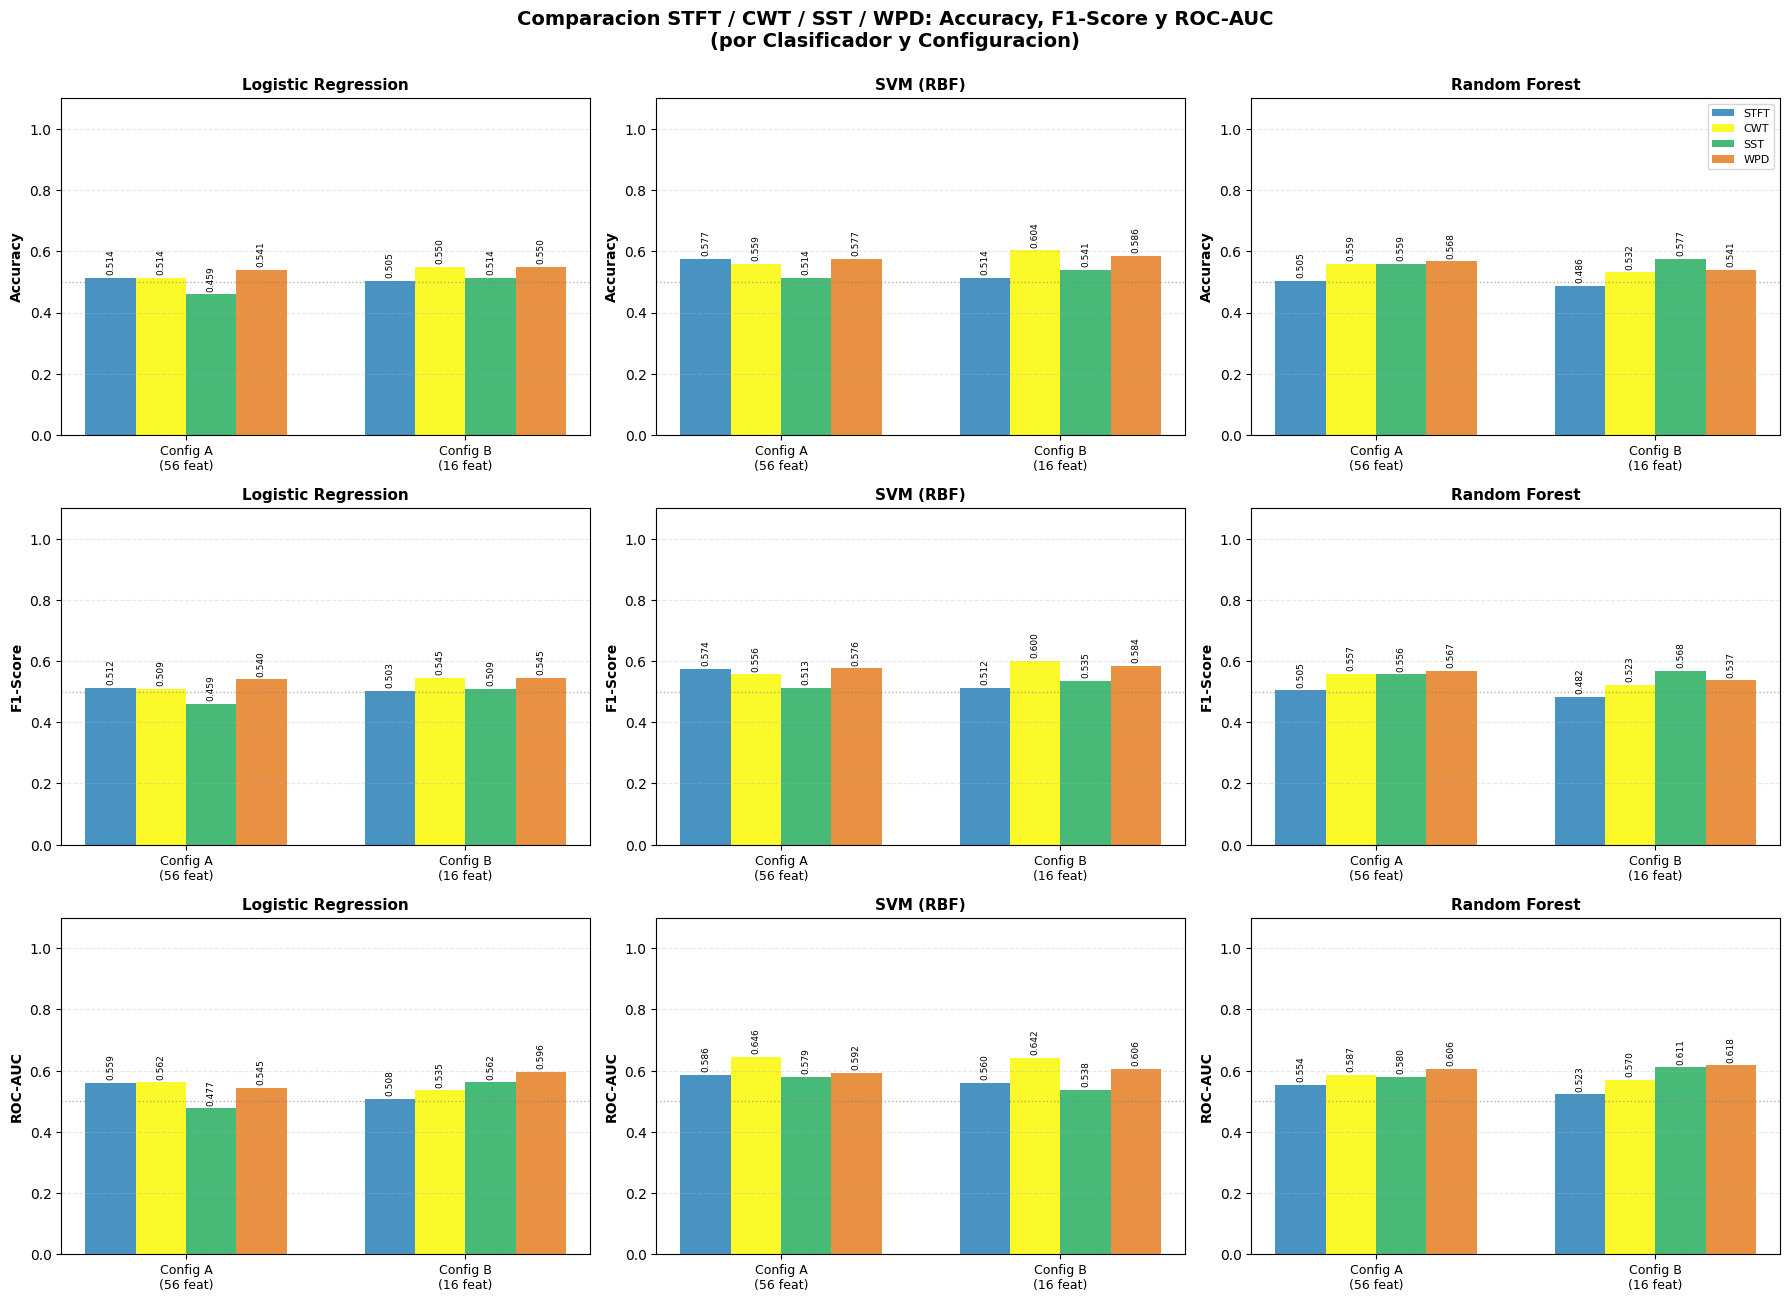

In [68]:
## Gráficos comparativos: 4 técnicas por métrica, clasificador y configuración

metrics   = ['Accuracy', 'F1-Score', 'ROC-AUC']
clf_names = list(classifiers.keys())
configs   = ['A (56 features)', 'B (16 features)']
x_pos     = np.arange(len(configs))
width     = 0.18
offsets   = [-1.5*width, -0.5*width, 0.5*width, 1.5*width]

fig, axes = plt.subplots(3, 3, figsize=(18, 13))
fig.suptitle('Comparacion STFT / CWT / SST / WPD: Accuracy, F1-Score y ROC-AUC\n(por Clasificador y Configuracion)',
             fontsize=14, fontweight='bold', y=0.998)

for mi, metric in enumerate(metrics):
    for ci, clf_name in enumerate(clf_names):
        ax = axes[mi, ci]
        subset = results_df[results_df['Clasificador'] == clf_name]

        for ti, tecnica in enumerate(TECNICAS):
            vals = []
            for cfg in configs:
                row = subset[(subset['Técnica'] == tecnica) & (subset['Config'] == cfg)]
                vals.append(row[metric].values[0])
            bars = ax.bar(x_pos + offsets[ti], vals, width,
                          label=tecnica, alpha=0.85, color=COLORS[tecnica])
            for bar in bars:
                h = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., h + 0.01,
                        f'{h:.3f}', ha='center', va='bottom', fontsize=6.5, rotation=90)

        ax.set_ylabel(metric, fontsize=10, fontweight='bold')
        ax.set_title(clf_name, fontsize=11, fontweight='bold')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(['Config A\n(56 feat)', 'Config B\n(16 feat)'], fontsize=9)
        ax.set_ylim([0.0, 1.1])
        ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.6, linewidth=1)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        if mi == 0 and ci == 2:
            ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()


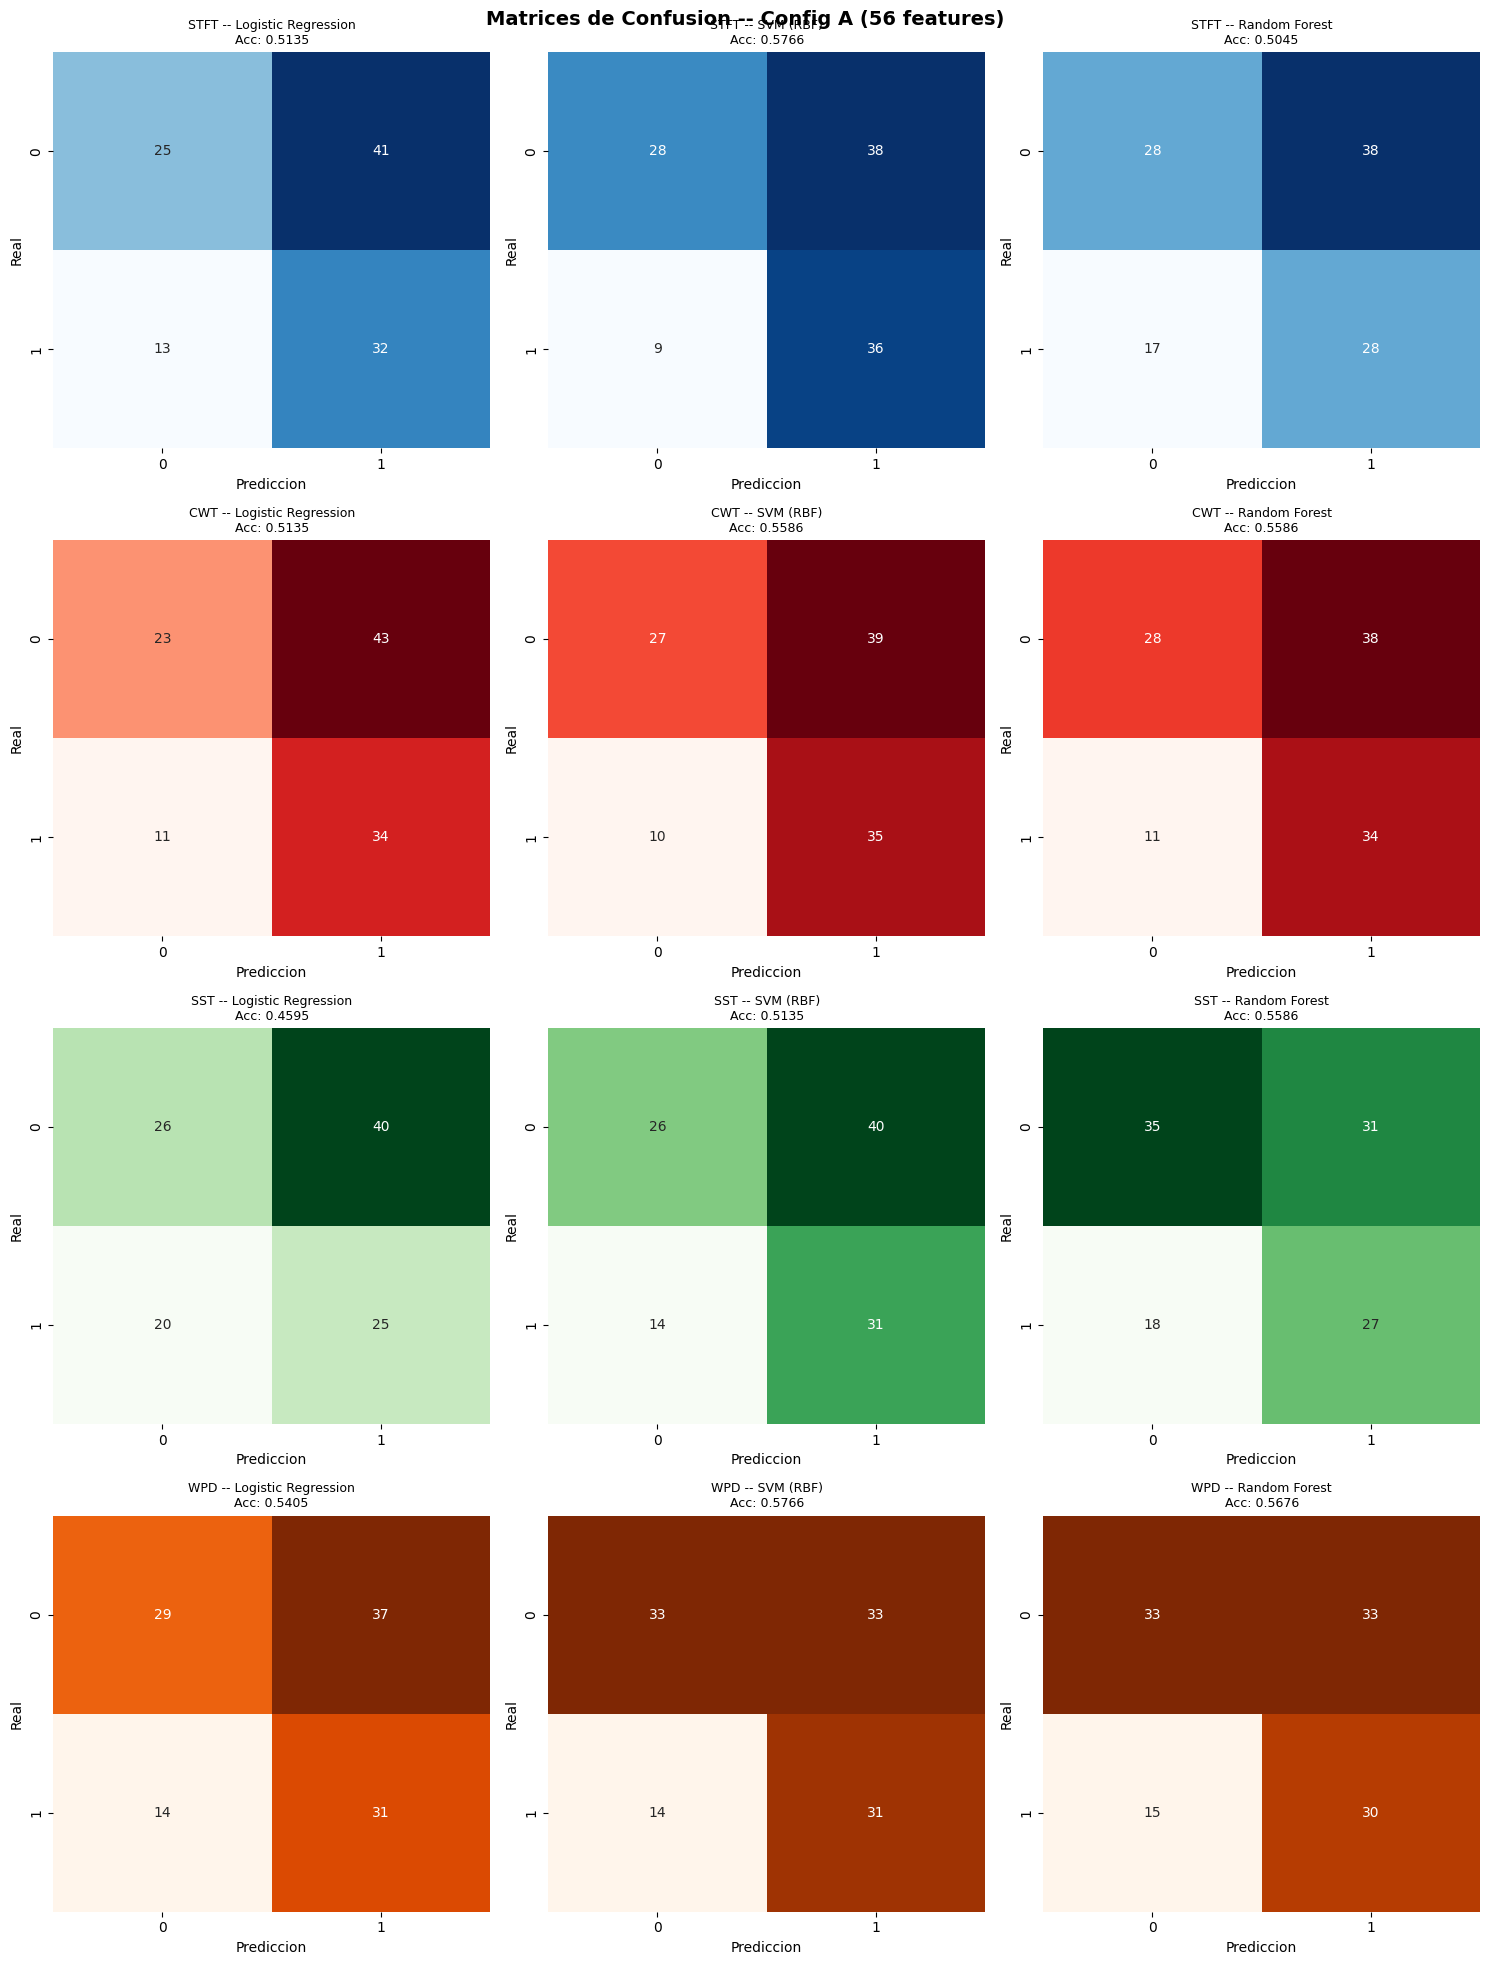

In [69]:
## Matrices de Confusión -- Config A (todos los canales, 56 features)

clf_names = list(classifiers.keys())
cmaps = {'STFT': 'Blues', 'CWT': 'Reds', 'SST': 'Greens', 'WPD': 'Oranges'}

fig, axes = plt.subplots(4, 3, figsize=(15, 20))
fig.suptitle('Matrices de Confusion -- Config A (56 features)', fontsize=14, fontweight='bold')

for ti, tecnica in enumerate(TECNICAS):
    for ci, clf_name in enumerate(clf_names):
        ax = axes[ti, ci]
        r = next(x for x in results if x['Técnica'] == tecnica
                 and x['Config'] == 'A (56 features)'
                 and x['Clasificador'] == clf_name)
        sns.heatmap(r['CM'], annot=True, fmt='d', cmap=cmaps[tecnica], ax=ax, cbar=False)
        ax.set_title(f'{tecnica} -- {clf_name}\nAcc: {r["Accuracy"]:.4f}', fontsize=9)
        ax.set_ylabel('Real')
        ax.set_xlabel('Prediccion')

plt.tight_layout()
plt.show()


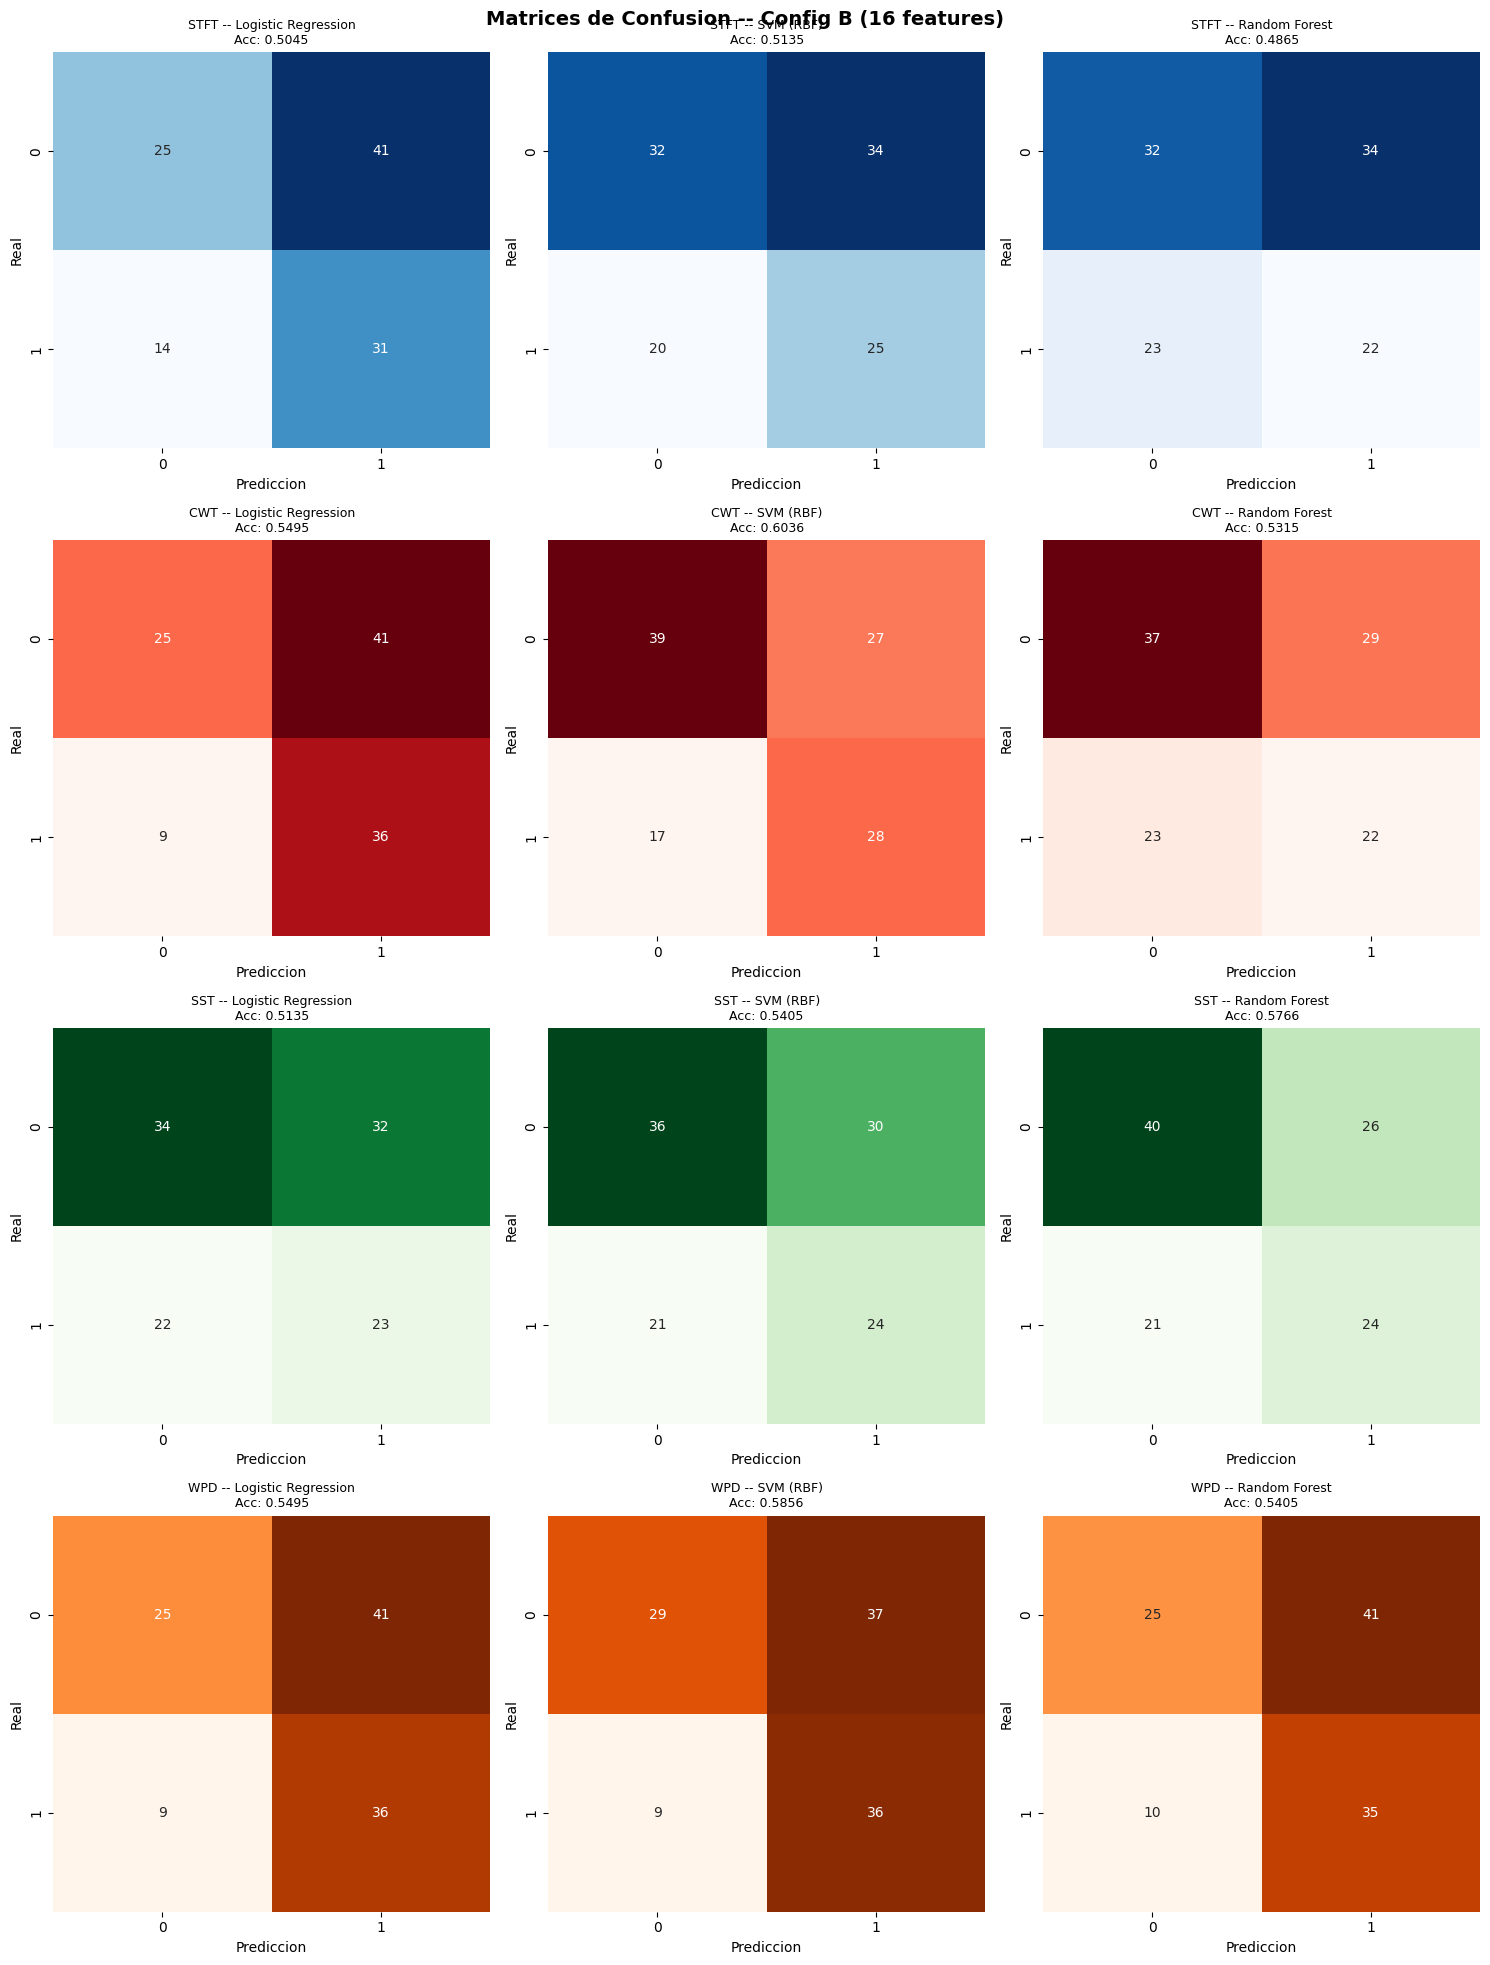

In [70]:
## Matrices de Confusion -- Config B (canales alfa, 16 features)

fig, axes = plt.subplots(4, 3, figsize=(15, 20))
fig.suptitle('Matrices de Confusion -- Config B (16 features)', fontsize=14, fontweight='bold')

for ti, tecnica in enumerate(TECNICAS):
    for ci, clf_name in enumerate(clf_names):
        ax = axes[ti, ci]
        r = next(x for x in results if x['Técnica'] == tecnica
                 and x['Config'] == 'B (16 features)'
                 and x['Clasificador'] == clf_name)
        sns.heatmap(r['CM'], annot=True, fmt='d', cmap=cmaps[tecnica], ax=ax, cbar=False)
        ax.set_title(f'{tecnica} -- {clf_name}\nAcc: {r["Accuracy"]:.4f}', fontsize=9)
        ax.set_ylabel('Real')
        ax.set_xlabel('Prediccion')

plt.tight_layout()
plt.show()


# Sección 3: Importancia de Features

Análisis del Random Forest para identificar qué canales contribuyen más a la clasificación y si dominan los canales fisiológicamente relevantes (O1, O2, P7, P8).

In [71]:
## Importancia de features -- Random Forest Config A (las 4 técnicas)

canales_alfa_list = ['O1', 'O2', 'P7', 'P8']
feature_names_a = [feature_names[i] for i in idx_config_a]

importance_by_tecnica = {}

for tecnica in TECNICAS:
    rf_result = next(r for r in results if r['Técnica'] == tecnica
                     and r['Config'] == 'A (56 features)'
                     and r['Clasificador'] == 'Random Forest')
    imp = rf_result['model'].feature_importances_
    imp_df = pd.DataFrame({'Feature': feature_names_a, 'Importance': imp})
    imp_df['Canal'] = imp_df['Feature'].str.split('_').str[0]
    canal_imp = imp_df.groupby('Canal')['Importance'].sum().sort_values(ascending=False)
    importance_by_tecnica[tecnica] = canal_imp

    pct_alfa = canal_imp[canal_imp.index.isin(canales_alfa_list)].sum() / canal_imp.sum() * 100
    print(f'{tecnica}: canal dominante = {canal_imp.index[0]} ({canal_imp.iloc[0]:.3f}) | canales alfa = {pct_alfa:.1f}%')


STFT: canal dominante = T7 (0.137) | canales alfa = 23.5%
CWT: canal dominante = T7 (0.110) | canales alfa = 22.5%
SST: canal dominante = FC5 (0.111) | canales alfa = 28.8%
WPD: canal dominante = FC5 (0.096) | canales alfa = 30.8%


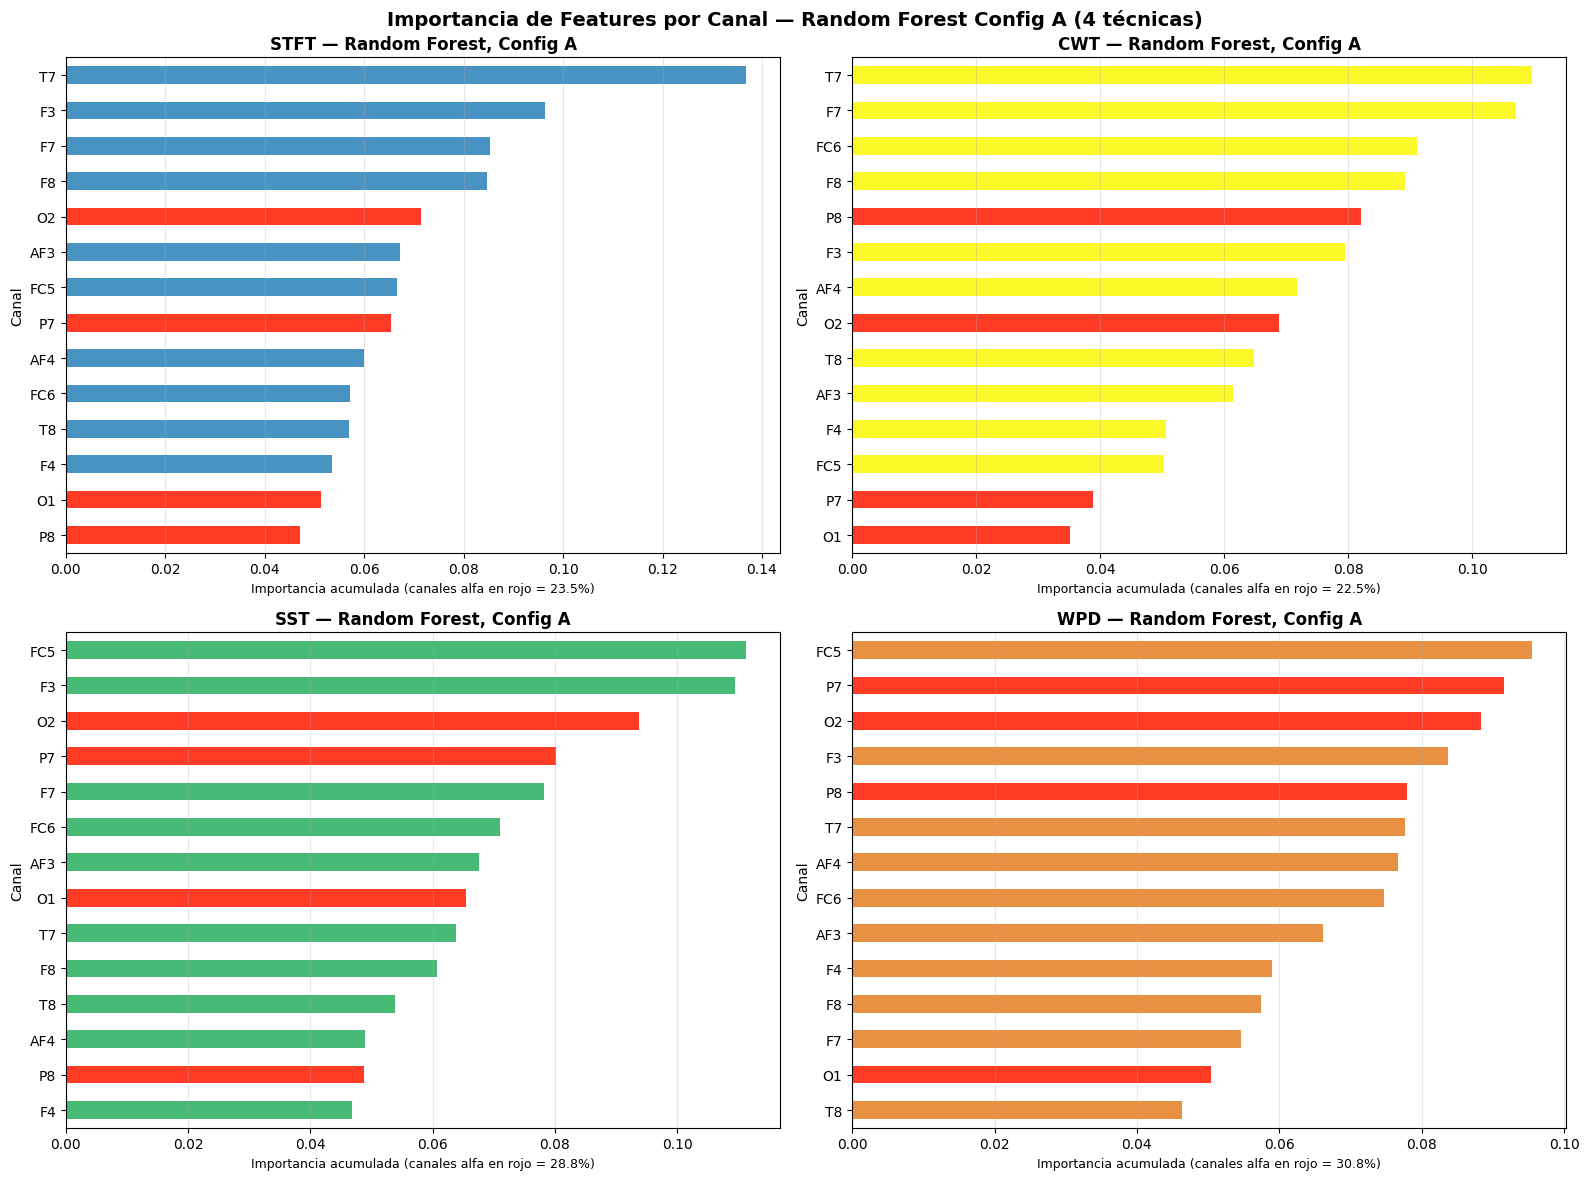

In [72]:
canales_alfa_list = ['O1', 'O2', 'P7', 'P8']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

fig.suptitle(
    'Importancia de Features por Canal — Random Forest Config A (4 técnicas)',
    fontsize=14,
    fontweight='bold'
)

for ax, tecnica in zip(axes.flat, TECNICAS):

    # Ordenar según las importancias de la propia técnica
    canal_imp = importance_by_tecnica[tecnica].sort_values(ascending=False)

    # Colorear canales alfa en rojo
    colors_bar = [
        "#ff1900" if canal in canales_alfa_list else COLORS[tecnica]
        for canal in canal_imp.index
    ]

    # Graficar
    canal_imp.plot(
        kind='barh',
        ax=ax,
        color=colors_bar,
        alpha=0.85
    )

    # Invertir eje para que el canal más importante quede arriba
    ax.invert_yaxis()

    # Porcentaje total de importancia de canales alfa
    pct = (
        importance_by_tecnica[tecnica]
        [importance_by_tecnica[tecnica].index.isin(canales_alfa_list)]
        .sum()
        / importance_by_tecnica[tecnica].sum()
        * 100
    )

    ax.set_title(
        f'{tecnica} — Random Forest, Config A',
        fontsize=12,
        fontweight='bold'
    )

    ax.set_xlabel(
        f'Importancia acumulada (canales alfa en rojo = {pct:.1f}%)',
        fontsize=9
    )

    ax.set_ylabel('Canal', fontsize=10)

    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Sección 4: Síntesis y conclusiones

Con las 24 combinaciones evaluadas (4 técnicas × 2 configuraciones × 3 clasificadores)
es posible establecer un ranking empírico de las representaciones tiempo-frecuencia
para la tarea de clasificación de estados ojos-abiertos vs ojos-cerrados.

**Rendimiento general:** ninguna técnica supera de forma consistente el 0.62 de accuracy
estándar, lo cual es esperable dado el desbalance entre train y test (ver notebook 07
para la evaluación con Balanced Accuracy y cross-validación temporal).

**Importancia de features:** en todas las técnicas dominan canales frontales y
temporales (F7, AF3, T7) por sobre los occipitales y parietales (O1, O2, P7, P8)
esperados para el ritmo alfa. Esto sugiere que los clasificadores capturan
principalmente artefactos oculares o musculares, no actividad alfa fisiológica pura.

**Config A vs Config B:** la restricción a canales alfa (Config B) reduce el
rendimiento en la mayoría de los casos, confirmando que los canales frontales
aportan poder discriminativo — aunque de origen artefactual.

Para una evaluación rigurosa que corrija el sesgo de distribución y la alta
varianza del split único, ver el **notebook 07**.
